#### Basic Concepts: Nodes, Edges & State


In [1]:
from typing import TypedDict
from langgraph.graph import START, END, StateGraph

In [2]:
class InputState(TypedDict):
    str_val: str
    num_val: int
    
def modify_state(input: InputState):
    print(f"Current state value: {input}")
    return input

In [3]:
g1 = StateGraph(InputState)

g1.add_node("branch_a", modify_state)
g1.add_node("branch_b", modify_state)
g1.add_edge(START, "branch_a")
g1.add_edge("branch_a", "branch_b")
g1.add_edge("branch_b", END)

# g1.set_entry_point("branch_a")

runnable = g1.compile()

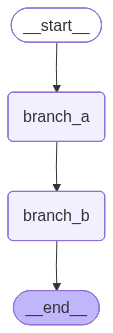

In [4]:
runnable

In [5]:
runnable.invoke({"str_val": "a"})

Current state value: {'str_val': 'a'}
Current state value: {'str_val': 'a'}


{'str_val': 'a'}

In [6]:
runnable.invoke({"str_val": "a", "num_val":1})

Current state value: {'str_val': 'a', 'num_val': 1}
Current state value: {'str_val': 'a', 'num_val': 1}


{'str_val': 'a', 'num_val': 1}

In [9]:
def modify_state(input: InputState):
    input['str_val'] += 'a'
    input['num_val'] += 1
    return input

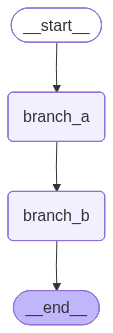

In [10]:
g1 = StateGraph(InputState)

g1.add_node("branch_a", modify_state)
g1.add_node("branch_b", modify_state)
g1.add_edge(START, "branch_a")
g1.add_edge("branch_a", "branch_b")
g1.add_edge("branch_b", END)
runnable = g1.compile()

runnable

In [15]:
runnable.invoke({"str_val": "a", "num_val":1})

{'str_val': 'aaa', 'num_val': 3}

#### Using LCEL


In [16]:
from langchain_core.runnables import RunnableLambda

In [17]:
runnable = RunnableLambda(modify_state)
runnable

RunnableLambda(modify_state)

In [19]:
chain = runnable | runnable
chain

RunnableLambda(modify_state)
| RunnableLambda(modify_state)

In [20]:
chain.invoke({"str_val": "a", "num_val":1})

{'str_val': 'aaa', 'num_val': 3}

In [21]:
runnable.invoke({"str_val": "a", "num_val":1})

{'str_val': 'aa', 'num_val': 2}

#### Conditional Routing


In [24]:
def modify_state(input: InputState):
    input['str_val'] += 'a'
    input['num_val'] += 1
    return input

def router(input: InputState):
    if input['num_val'] < 5:
        return "branch_a"
    else:
        return "__end__"

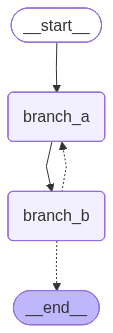

In [25]:
g2 = StateGraph(InputState)

g2.add_node("branch_a", modify_state)
g2.add_node("branch_b", modify_state)

g2.add_edge(START, "branch_a")
g2.add_edge("branch_a", "branch_b")
g2.add_conditional_edges("branch_b", router, {"branch_a": "branch_a",
"__end__": END})

run2 = g2.compile()
run2

In [26]:
run2.invoke({"str_val": "a", "num_val":1})

{'str_val': 'aaaaa', 'num_val': 5}